# Stock Return Prediction — Ridge, Lasso, ElasticNet
**Target:** Raw `Stock_Return` (%)  
**Evaluation metric:** RMSE  
**Tuning:** Optuna minimises CV-RMSE  
**Split:** Train 2014–2017 → Test 2018

## Cell 0 — Imports

In [15]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import VarianceThreshold
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import r2_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi']        = 130
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False


---
## Step 1 — Load & Combine Data

In [16]:
df = pd.read_csv("cleaned_dataset.csv")
df  = df.sort_values(['Ticker', 'Year']).reset_index(drop=True)

print(f'Shape   : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Years   : {sorted(df["Year"].unique())}')
print(f'Tickers : {df["Ticker"].nunique():,}')
print()
print('Stock_Return stats by year:')
print(df.groupby('Year')['Stock_Return']
        .agg(Mean='mean', Std='std', Min='min', Max='max')
        .round(2).to_string())

Shape   : 22,031 rows x 207 columns
Years   : [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
Tickers : 4,980

Stock_Return stats by year:
         Mean     Std       Min      Max
Year                                    
2014  -5.0000 43.1600  -98.3300 786.4900
2015  20.4800 54.2100  -99.9500 961.5400
2016  17.5600 55.2300 -100.0000 788.9900
2017 -13.4600 40.8500 -100.0000 975.6100
2018  19.6600 57.3000  -99.8600 844.1900


---
## Step 2 — Target Variable

`Stock_Return` is used directly as the target.  
It is pre-labelled: the value at year *t* represents the actual return for year *t+1*.  
No shifting or normalisation is applied.

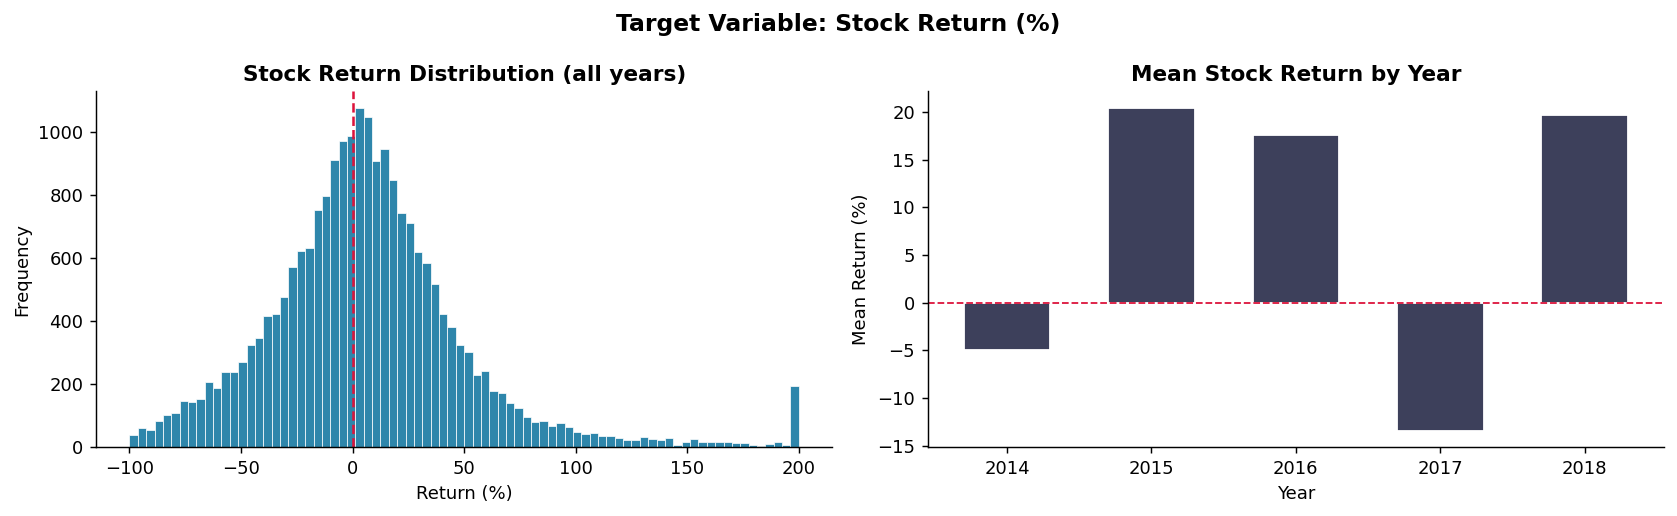

In [17]:
TARGET_COL = 'Stock_Return'

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df[TARGET_COL].clip(-100, 200), bins=80,
             color='#2E86AB', edgecolor='white', linewidth=0.4)
axes[0].axvline(0, color='crimson', linestyle='--', linewidth=1.4)
axes[0].set_title('Stock Return Distribution (all years)', fontweight='bold')
axes[0].set_xlabel('Return (%)')
axes[0].set_ylabel('Frequency')

df.groupby('Year')[TARGET_COL].mean().plot(
    kind='bar', ax=axes[1], color='#3D405B', edgecolor='white', width=0.6)
axes[1].set_title('Mean Stock Return by Year', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean Return (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].axhline(0, color='crimson', linestyle='--', linewidth=1)

plt.suptitle('Target Variable: Stock Return (%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('00_target.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Step 3 — Define Features & Remove Leakage

In [18]:
LEAKAGE   = ['Class', 'Return_Direction']   # derived from target
ID_COLS   = ['Ticker', 'Year']
CAT_FEATS = ['Sector']

exclude = LEAKAGE + ID_COLS + [TARGET_COL] + CAT_FEATS
NUMERIC_RAW = [
    c for c in df.columns
    if c not in exclude
    and df[c].dtype in [np.float64, np.float32, np.int64, np.int32]
]

print(f'Numeric features : {len(NUMERIC_RAW)}')
print(f'Categorical      : {CAT_FEATS}')
print(f'Leakage removed  : {LEAKAGE}')

miss = df[NUMERIC_RAW].isnull().mean()
print(f'Features >50% missing : {(miss > 0.5).sum()}')
print(f'Features   0% missing : {(miss == 0.0).sum()}')

Numeric features : 201
Categorical      : ['Sector']
Leakage removed  : ['Class', 'Return_Direction']
Features >50% missing : 0
Features   0% missing : 201


---
## Step 4 — Time-Based Train / Test Split

In [19]:
TRAIN_YEARS = [2014, 2015, 2016, 2017]
TEST_YEAR   = 2018

train_df = df[df['Year'].isin(TRAIN_YEARS)].copy().reset_index(drop=True)
test_df  = df[df['Year'] == TEST_YEAR].copy().reset_index(drop=True)

y_train = train_df[TARGET_COL].reset_index(drop=True)
y_test  = test_df[TARGET_COL].reset_index(drop=True)

print(f'Train (2014-2017) : {len(train_df):,} rows')
print(f'Test  (2018)      : {len(test_df):,} rows')
print(f'Train target mean : {y_train.mean():.2f}%  std: {y_train.std():.2f}%')
print(f'Test  target mean : {y_test.mean():.2f}%  std: {y_test.std():.2f}%')

# Expanding-window CV folds (within training period only)
CV_SPLITS = [
    ([2014],             2015),
    ([2014, 2015],       2016),
    ([2014, 2015, 2016], 2017),
]

Train (2014-2017) : 17,641 rows
Test  (2018)      : 4,390 rows
Train target mean : 4.68%  std: 50.95%
Test  target mean : 19.66%  std: 57.30%


---
## Step 5 — Feature Engineering

All parameters (percentiles, means, medians) fitted on **training data only**.

| Step | Transform | Purpose |
|------|-----------|---------|
| 5.1 | Winsorisation (1–99th pct) | Clip outliers |
| 5.2 | Signed-log on size variables | Compress skewed distributions |
| 5.3 | Cross-sectional z-score per year | Remove year-scale differences in *features* |
| 5.4 | Sector-relative adjustment | Remove sector-level bias in features |
| 5.5 | Delta features (YoY changes) | Momentum / change signals |
| 5.6 | Interaction features | Value x Quality, Growth x Quality |

> **Note:** Only the *features* are cross-sectionally normalised.  
> The *target* (`Stock_Return`) is kept as raw return percentages.

In [20]:
# 5.1  Winsorisation (fit on train only)
print('5.1  Winsorisation ...')
winsor_bounds = {}
X_tr_w = train_df[NUMERIC_RAW].copy()

for col in NUMERIC_RAW:
    lo = X_tr_w[col].quantile(0.01)
    hi = X_tr_w[col].quantile(0.99)
    winsor_bounds[col] = (lo, hi)
    X_tr_w[col] = X_tr_w[col].clip(lo, hi)

X_te_w = test_df[NUMERIC_RAW].copy()
for col, (lo, hi) in winsor_bounds.items():
    X_te_w[col] = X_te_w[col].clip(lo, hi)
print('     Done')

# 5.2  Signed-log on size variables
print('5.2  Signed-log ...')
SIZE_VARS = [c for c in ['Revenue', 'Total assets', 'Market Cap', 'Enterprise Value']
             if c in NUMERIC_RAW]

def signed_log(s):
    return np.sign(s) * np.log1p(np.abs(s))

for col in SIZE_VARS:
    X_tr_w[col] = signed_log(X_tr_w[col])
    X_te_w[col] = signed_log(X_te_w[col])
print(f'     Applied to: {SIZE_VARS}')
print('     Done')

5.1  Winsorisation ...
     Done
5.2  Signed-log ...
     Applied to: ['Revenue', 'Total assets', 'Market Cap', 'Enterprise Value']
     Done


In [21]:
# 5.3  Cross-sectional z-score per year on FEATURES (not target)
print('5.3  Feature cross-sectional z-score ...')
year_stats = {}
for yr in TRAIN_YEARS:
    mask = (train_df['Year'] == yr)
    year_stats[yr] = {
        'mean': X_tr_w[mask].mean(),
        'std':  X_tr_w[mask].std().replace(0, 1),
    }

def cs_std(X_feat, year_series, stats, fallback=2017):
    out = X_feat.copy()
    for yr in year_series.unique():
        ref  = yr if yr in stats else fallback
        mask = (year_series == yr)
        out.loc[mask] = (X_feat.loc[mask] - stats[ref]['mean']) / stats[ref]['std']
    return out

X_tr_cs = cs_std(X_tr_w, train_df['Year'], year_stats)
X_te_cs = cs_std(X_te_w, test_df['Year'],  year_stats)
print('     Done')

# 5.4  Sector-relative adjustment
print('5.4  Sector-relative adjustment ...')
sector_meds = {}
for sec in train_df['Sector'].unique():
    mask = (train_df['Sector'] == sec)
    sector_meds[sec] = X_tr_cs[mask].median()
fallback_sec = train_df['Sector'].mode()[0]

def sector_adj(X_feat, sector_series, meds, fallback):
    out = X_feat.copy()
    for sec in sector_series.unique():
        med  = meds.get(sec, meds[fallback])
        mask = (sector_series == sec)
        out.loc[mask] = X_feat.loc[mask] - med
    return out

X_tr_sa = sector_adj(X_tr_cs, train_df['Sector'], sector_meds, fallback_sec)
X_te_sa = sector_adj(X_te_cs, test_df['Sector'],  sector_meds, fallback_sec)
print('     Done')

5.3  Feature cross-sectional z-score ...
     Done
5.4  Sector-relative adjustment ...
     Done


In [22]:
# 5.5  Delta features (YoY changes)
print('5.5  Delta features ...')
DELTA_MAP = {
    'd_NetProfitMargin' : 'Net Profit Margin',
    'd_ROE'             : 'ROE',
    'd_DebtToEquity'    : 'Debt to Equity',
    'd_RevenueGrowth'   : 'Revenue Growth',
    'd_GrossMargin'     : 'Gross Margin',
    'd_OperatingMargin' : 'EBIT Margin',
}
for new_col, src in DELTA_MAP.items():
    if src in df.columns:
        df[new_col] = df.groupby('Ticker')[src].diff()

DELTA_COLS = [c for c in DELTA_MAP if c in df.columns]
delta_tr = df[df['Year'].isin(TRAIN_YEARS)][DELTA_COLS].reset_index(drop=True)
delta_te = df[df['Year'] == TEST_YEAR][DELTA_COLS].reset_index(drop=True)

for col in DELTA_COLS:
    lo = delta_tr[col].quantile(0.01)
    hi = delta_tr[col].quantile(0.99)
    delta_tr[col] = delta_tr[col].clip(lo, hi)
    delta_te[col] = delta_te[col].clip(lo, hi)
print(f'     Created: {DELTA_COLS}')

# 5.6  Interaction features
print('5.6  Interaction features ...')
VALUE_PROXY   = next((f for f in ['priceToBookRatio', 'priceEarningsRatio', 'priceFairValue']
                      if f in NUMERIC_RAW), None)
QUALITY_PROXY = next((f for f in ['returnOnEquity', 'ROE', 'returnOnAssets']
                      if f in NUMERIC_RAW), None)
GROWTH_PROXY  = next((f for f in ['Revenue Growth', 'EPS Growth', 'Net Income Growth']
                      if f in NUMERIC_RAW), None)
MARGIN_PROXY  = next((f for f in ['Net Profit Margin', 'Gross Margin', 'EBIT Margin']
                      if f in NUMERIC_RAW), None)

INTERACTION_COLS = []
ix_tr_parts, ix_te_parts = [], []
pairs = []
if VALUE_PROXY   and QUALITY_PROXY: pairs.append((VALUE_PROXY,  QUALITY_PROXY,  'ix_Value_Quality'))
if GROWTH_PROXY  and QUALITY_PROXY: pairs.append((GROWTH_PROXY, QUALITY_PROXY,  'ix_Growth_Quality'))
if MARGIN_PROXY  and GROWTH_PROXY:  pairs.append((MARGIN_PROXY, GROWTH_PROXY,   'ix_Margin_Growth'))

for col_a, col_b, name in pairs:
    tr_col = (X_tr_cs[col_a].fillna(0) * X_tr_cs[col_b].fillna(0)).rename(name)
    te_col = (X_te_cs[col_a].fillna(0) * X_te_cs[col_b].fillna(0)).rename(name)
    lo, hi = tr_col.quantile(0.01), tr_col.quantile(0.99)
    ix_tr_parts.append(tr_col.clip(lo, hi))
    ix_te_parts.append(te_col.clip(lo, hi))
    INTERACTION_COLS.append(name)
print(f'     Created: {INTERACTION_COLS}')

# Assemble final matrices
NUMERIC_ENG = NUMERIC_RAW + DELTA_COLS + INTERACTION_COLS
parts_tr = [X_tr_sa.reset_index(drop=True), delta_tr]
parts_te = [X_te_sa.reset_index(drop=True), delta_te]
if ix_tr_parts:
    parts_tr.append(pd.concat(ix_tr_parts, axis=1).reset_index(drop=True))
    parts_te.append(pd.concat(ix_te_parts, axis=1).reset_index(drop=True))

X_train_eng = pd.concat(parts_tr, axis=1)
X_test_eng  = pd.concat(parts_te, axis=1)
X_train_eng['Sector'] = train_df['Sector'].values
X_test_eng['Sector']  = test_df['Sector'].values

print(f'Feature engineering complete: {len(NUMERIC_ENG)} numeric features total')

5.5  Delta features ...
     Created: ['d_NetProfitMargin', 'd_ROE', 'd_DebtToEquity', 'd_RevenueGrowth', 'd_GrossMargin', 'd_OperatingMargin']
5.6  Interaction features ...
     Created: ['ix_Value_Quality', 'ix_Growth_Quality', 'ix_Margin_Growth']
Feature engineering complete: 210 numeric features total


---
## Step 6 — Feature Selection

Three sequential filters, all computed on training data only:

1. **Variance filter** — remove near-constant features (threshold = 0.01)
2. **Correlation filter** — remove one from any pair with |r| > 0.92
3. **Univariate selection** — keep top 60 by |Pearson r| with raw `Stock_Return`

In [23]:
# 6.1  Variance filter
print('6.1  Variance filter ...')
_imp  = SimpleImputer(strategy='median')
X_chk = pd.DataFrame(
    _imp.fit_transform(X_train_eng[NUMERIC_ENG]),
    columns=NUMERIC_ENG
)
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_chk)
hv_feats = [f for f, k in zip(NUMERIC_ENG, vt.get_support()) if k]
print(f'     Dropped {len(NUMERIC_ENG)-len(hv_feats)} | Remaining: {len(hv_feats)}')

# 6.2  Correlation filter
print('6.2  Correlation filter (|r| > 0.92) ...')
X_hv  = X_chk[hv_feats]
upper = X_hv.corr().abs().where(
    np.triu(np.ones((len(hv_feats), len(hv_feats))), k=1).astype(bool))
drop_c    = [c for c in upper.columns if any(upper[c] > 0.92)]
sel_feats = [f for f in hv_feats if f not in drop_c]
print(f'     Dropped {len(drop_c)} | Remaining: {len(sel_feats)}')

# 6.3  Pearson r with raw Stock_Return — top 60
print('6.3  Pearson r selection (top 60) ...')
X_imp  = X_hv[sel_feats].fillna(X_hv[sel_feats].median())
y_arr  = y_train.values

from scipy.stats import pearsonr
r_map = {}
for col in sel_feats:
    r, _ = pearsonr(X_imp[col].values, y_arr)
    r_map[col] = abs(r)

r_series    = pd.Series(r_map).sort_values(ascending=False)
FINAL_FEATS = r_series.head(60).index.tolist()
print(f'     Final: {len(FINAL_FEATS)} features')
print()
print('Top 15 features by |Pearson r| with Stock_Return:')
print(r_series.head(15).to_string())

6.1  Variance filter ...
     Dropped 2 | Remaining: 208
6.2  Correlation filter (|r| > 0.92) ...
     Dropped 53 | Remaining: 155
6.3  Pearson r selection (top 60) ...
     Final: 60 features

Top 15 features by |Pearson r| with Stock_Return:
EPS                                      0.1345
freeCashFlowPerShare                     0.0976
Book Value per Share                     0.0728
priceToSalesRatio                        0.0683
EBITDA Margin                            0.0676
returnOnCapitalEmployed                  0.0642
Weighted Average Shares Growth           0.0639
EBIT Margin                              0.0615
Weighted Average Shares Diluted Growth   0.0591
EV to Sales                              0.0573
priceSalesRatio                          0.0567
SG&A Expenses Growth                     0.0549
Revenue                                  0.0502
Asset Growth                             0.0493
Tangible Book Value per Share            0.0484


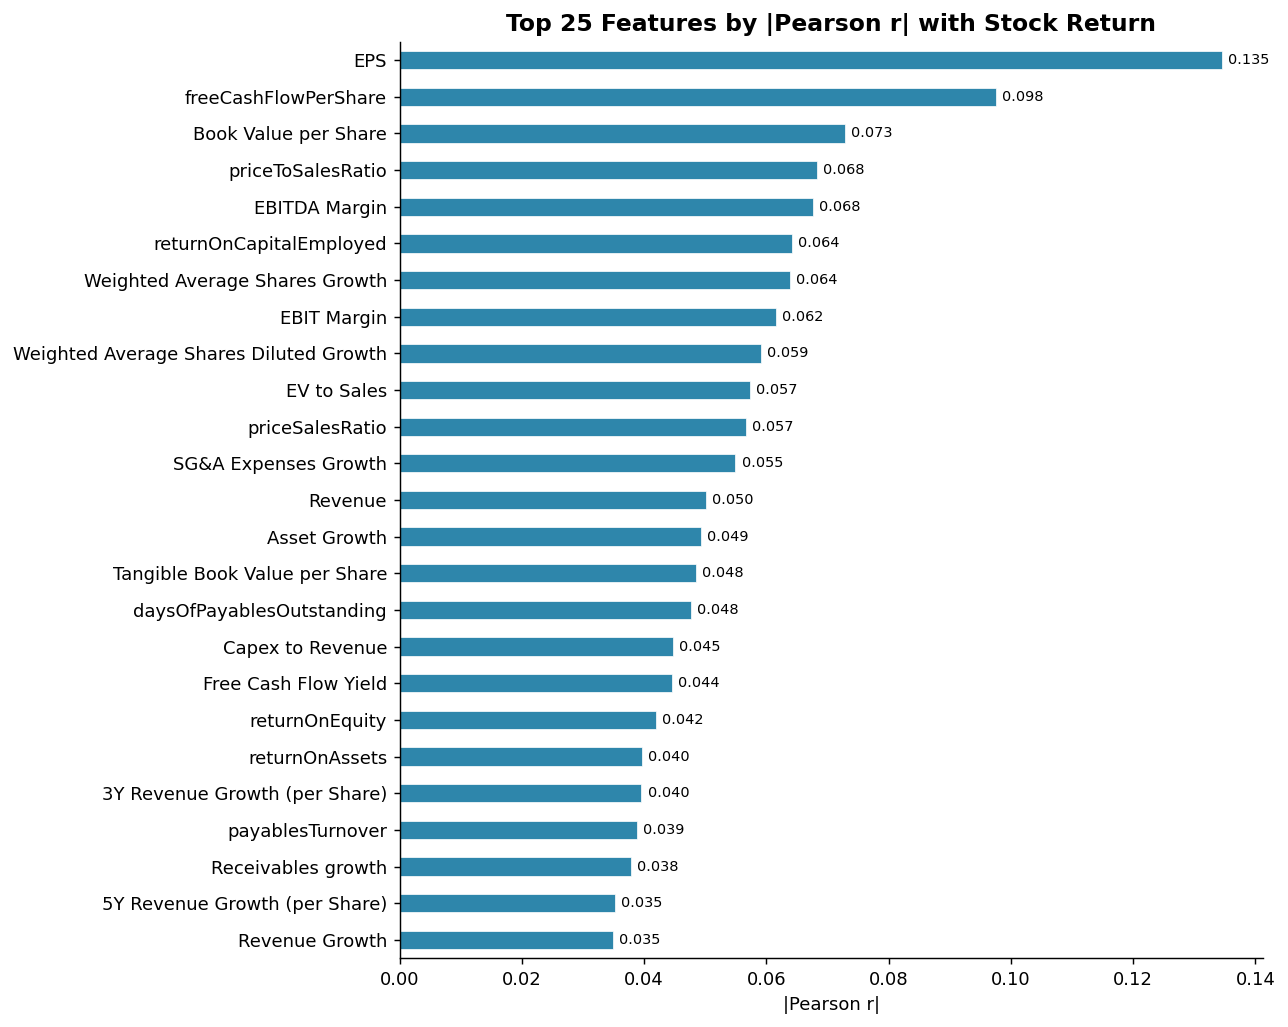

Saved: 01_feature_importance.png


In [24]:
fig, ax = plt.subplots(figsize=(10, 8))
r_series.head(25).sort_values().plot(
    kind='barh', ax=ax, color='#2E86AB', edgecolor='white', linewidth=0.4)
ax.set_title('Top 25 Features by |Pearson r| with Stock Return',
             fontsize=13, fontweight='bold')
ax.set_xlabel('|Pearson r|')
for i, val in enumerate(r_series.head(25).sort_values()):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('01_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: 01_feature_importance.png')

---
## Step 7 — Preprocessing Pipeline & CV Helper

In [25]:
def make_preprocessor(num_feats):
    return ColumnTransformer([
        ('num', Pipeline([
            ('imp',    SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_feats),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), CAT_FEATS),
    ])


def cv_rmse(pipeline, num_feats):
    # Mean RMSE across 3 expanding folds — used as Optuna objective.
    rmses = []
    for train_yrs, val_yr in CV_SPLITS:
        tr = train_df['Year'].isin(train_yrs)
        va = train_df['Year'] == val_yr
        pipeline.fit(
            X_train_eng.loc[tr, num_feats + CAT_FEATS],
            y_train.loc[tr]
        )
        preds = pipeline.predict(X_train_eng.loc[va, num_feats + CAT_FEATS])
        rmse  = np.sqrt(mean_squared_error(y_train.loc[va], preds))
        rmses.append(rmse)
    return float(np.mean(rmses))


print(f'Preprocessor ready: {len(FINAL_FEATS)} numeric + {len(CAT_FEATS)} categorical')
print('CV objective: minimise mean RMSE over 3 expanding folds')

Preprocessor ready: 60 numeric + 1 categorical
CV objective: minimise mean RMSE over 3 expanding folds


---
## Step 8 — Experiment 1: Baseline OLS Linear Regression

In [27]:
print('=' * 60)
print('  EXPERIMENT 1 - Baseline OLS Linear Regression')
print('=' * 60)

pipe_lr = Pipeline([
    ('prep',  make_preprocessor(FINAL_FEATS)),
    ('model', LinearRegression()),
])

print('Expanding-window CV:')
lr_rmses, lr_r2s = [], []
for train_yrs, val_yr in CV_SPLITS:
    tr = train_df['Year'].isin(train_yrs)
    va = train_df['Year'] == val_yr
    pipe_lr.fit(X_train_eng.loc[tr, FINAL_FEATS + CAT_FEATS], y_train.loc[tr])
    preds = pipe_lr.predict(X_train_eng.loc[va, FINAL_FEATS + CAT_FEATS])
    rmse  = np.sqrt(mean_squared_error(y_train.loc[va], preds))
    r2    = r2_score(y_train.loc[va], preds)
    lr_rmses.append(rmse)
    lr_r2s.append(r2)
    print(f'  Train {train_yrs} -> Val {val_yr} | RMSE = {rmse:.4f}  R² = {r2:.4f}')
print(f'  Mean CV RMSE : {np.mean(lr_rmses):.4f}')
print(f'  Mean CV R²   : {np.mean(lr_r2s):.4f}')

# Final fit on full training set
pipe_lr.fit(X_train_eng[FINAL_FEATS + CAT_FEATS], y_train)
pred_lr   = pipe_lr.predict(X_test_eng[FINAL_FEATS + CAT_FEATS])
rmse_lr   = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr     = r2_score(y_test, pred_lr)
print(f'  Test RMSE    : {rmse_lr:.4f}')
print(f'  Test R²      : {r2_lr:.4f}')

  EXPERIMENT 1 - Baseline OLS Linear Regression
Expanding-window CV:
  Train [2014] -> Val 2015 | RMSE = 62.6011  R² = -0.3338
  Train [2014, 2015] -> Val 2016 | RMSE = 56.5670  R² = -0.0494
  Train [2014, 2015, 2016] -> Val 2017 | RMSE = 47.5439  R² = -0.3549
  Mean CV RMSE : 55.5707
  Mean CV R²   : -0.2460
  Test RMSE    : 58.8426
  Test R²      : -0.0547


---
## Step 9 — Experiment 2: Ridge / Lasso / ElasticNet (Optuna)

Optuna **minimises CV-RMSE** over 100 trials using Bayesian TPE search.

| Model | Alpha search space | Notes |
|-------|--------------------|-------|
| Ridge | [0.01, 500] log-uniform | L2 penalty only |
| Lasso | [1e-4, 2.0] log-uniform | L1 penalty — narrow range avoids zeroing all coefs |
| ElasticNet | alpha [1e-4, 5.0], l1_ratio [0.05, 0.95] | Combined L1 + L2 |

In [28]:
print('=' * 60)
print('  EXPERIMENT 2 - Ridge / Lasso / ElasticNet  (Optuna)')
print('=' * 60)

N_TRIALS = 100
results_reg    = {}
best_reg_pipes = {}

SEARCH_SPACES = {
    'Ridge'      : {'alpha': (1e-2, 5e2)},
    'Lasso'      : {'alpha': (1e-4, 2.0)},
    'ElasticNet' : {'alpha': (1e-4, 5.0), 'l1_ratio': (0.05, 0.95)},
}

def make_objective(ModelCls, model_name):
    # Factory pattern — binds ModelCls at creation time to fix closure bug.
    def objective(trial):
        sp    = SEARCH_SPACES[model_name]
        alpha = trial.suggest_float('alpha', sp['alpha'][0], sp['alpha'][1], log=True)
        kw    = {'alpha': alpha, 'max_iter': 20000}
        if ModelCls is ElasticNet:
            kw['l1_ratio'] = trial.suggest_float(
                'l1_ratio', sp['l1_ratio'][0], sp['l1_ratio'][1])
        pipe = Pipeline([
            ('prep',  make_preprocessor(FINAL_FEATS)),
            ('model', ModelCls(**kw)),
        ])
        rmse = cv_rmse(pipe, FINAL_FEATS)
        if np.isnan(rmse):
            raise optuna.exceptions.TrialPruned()
        return rmse   # Optuna minimises RMSE only; R² tracked separately for reporting
    return objective

for ModelClass, name in [(Ridge, 'Ridge'), (Lasso, 'Lasso'), (ElasticNet, 'ElasticNet')]:
    print(f'\n-- Tuning {name} ({N_TRIALS} trials) ...')
    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
    )
    study.optimize(
        make_objective(ModelClass, name),
        n_trials=N_TRIALS,
        show_progress_bar=False,
    )
    bp = study.best_params
    print(f'   Best params    : {bp}')
    print(f'   Best CV RMSE   : {study.best_value:.4f}')

    kw = {**bp, 'max_iter': 20000}
    best_pipe = Pipeline([
        ('prep',  make_preprocessor(FINAL_FEATS)),
        ('model', ModelClass(**kw)),
    ])
    best_pipe.fit(X_train_eng[FINAL_FEATS + CAT_FEATS], y_train)
    best_reg_pipes[name] = best_pipe

    preds     = best_pipe.predict(X_test_eng[FINAL_FEATS + CAT_FEATS])
    test_rmse = np.sqrt(mean_squared_error(y_test, preds))
    test_r2   = r2_score(y_test, preds)
    results_reg[name] = {
        'Best_Params': str(bp),
        'CV_RMSE'    : study.best_value,
        'Test_RMSE'  : test_rmse,
        'Test_R2'    : test_r2,
    }
    print(f'   Test RMSE      : {test_rmse:.4f}')
    print(f'   Test R²        : {test_r2:.4f}')

print('\nExperiment 2 complete.')

  EXPERIMENT 2 - Ridge / Lasso / ElasticNet  (Optuna)

-- Tuning Ridge (100 trials) ...
   Best params    : {'alpha': 498.3340415962662}
   Best CV RMSE   : 54.8375
   Test RMSE      : 58.8147
   Test R²        : -0.0537

-- Tuning Lasso (100 trials) ...
   Best params    : {'alpha': 1.8646177887999302}
   Best CV RMSE   : 54.2905
   Test RMSE      : 58.7933
   Test R²        : -0.0529

-- Tuning ElasticNet (100 trials) ...
   Best params    : {'alpha': 2.0914165559105315, 'l1_ratio': 0.9136543299475239}
   Best CV RMSE   : 54.3039
   Test RMSE      : 58.8352
   Test R²        : -0.0544

Experiment 2 complete.


---
## Step 10 — Collect All Results

In [31]:

all_preds = {
    'OLS Baseline'       : pred_lr,
    'Ridge (Optuna)'     : best_reg_pipes['Ridge'].predict(X_test_eng[FINAL_FEATS + CAT_FEATS]),
    'Lasso (Optuna)'     : best_reg_pipes['Lasso'].predict(X_test_eng[FINAL_FEATS + CAT_FEATS]),
    'ElasticNet (Optuna)': best_reg_pipes['ElasticNet'].predict(X_test_eng[FINAL_FEATS + CAT_FEATS]),
}

results_rows = {}
for name, preds in all_preds.items():
    results_rows[name] = {
        'Test_RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'Test_R2'  : r2_score(y_test, preds),
    }

results_df = pd.DataFrame(results_rows).T.sort_values('Test_RMSE')
best_model = results_df['Test_RMSE'].idxmin()

print('=' * 55)
print('  TEST RESULTS — Test Set (2018)')
print('=' * 55)
print(results_df[['Test_RMSE', 'Test_R2']].to_string())
print(f'\nBest model : {best_model}')
print(f'  RMSE     : {results_df.loc[best_model, "Test_RMSE"]:.4f}')
print(f'  R²       : {results_df.loc[best_model, "Test_R2"]:.4f}')


  TEST RESULTS — Test Set (2018)
                     Test_RMSE  Test_R2
Lasso (Optuna)         58.7933  -0.0529
Ridge (Optuna)         58.8147  -0.0537
ElasticNet (Optuna)    58.8352  -0.0544
OLS Baseline           58.8426  -0.0547

Best model : Lasso (Optuna)
  RMSE     : 58.7933
  R²       : -0.0529


---
## Step 11 — Performance Dashboard

One chart per model: actual vs predicted, plus a RMSE comparison bar chart.
Best model highlighted in gold.

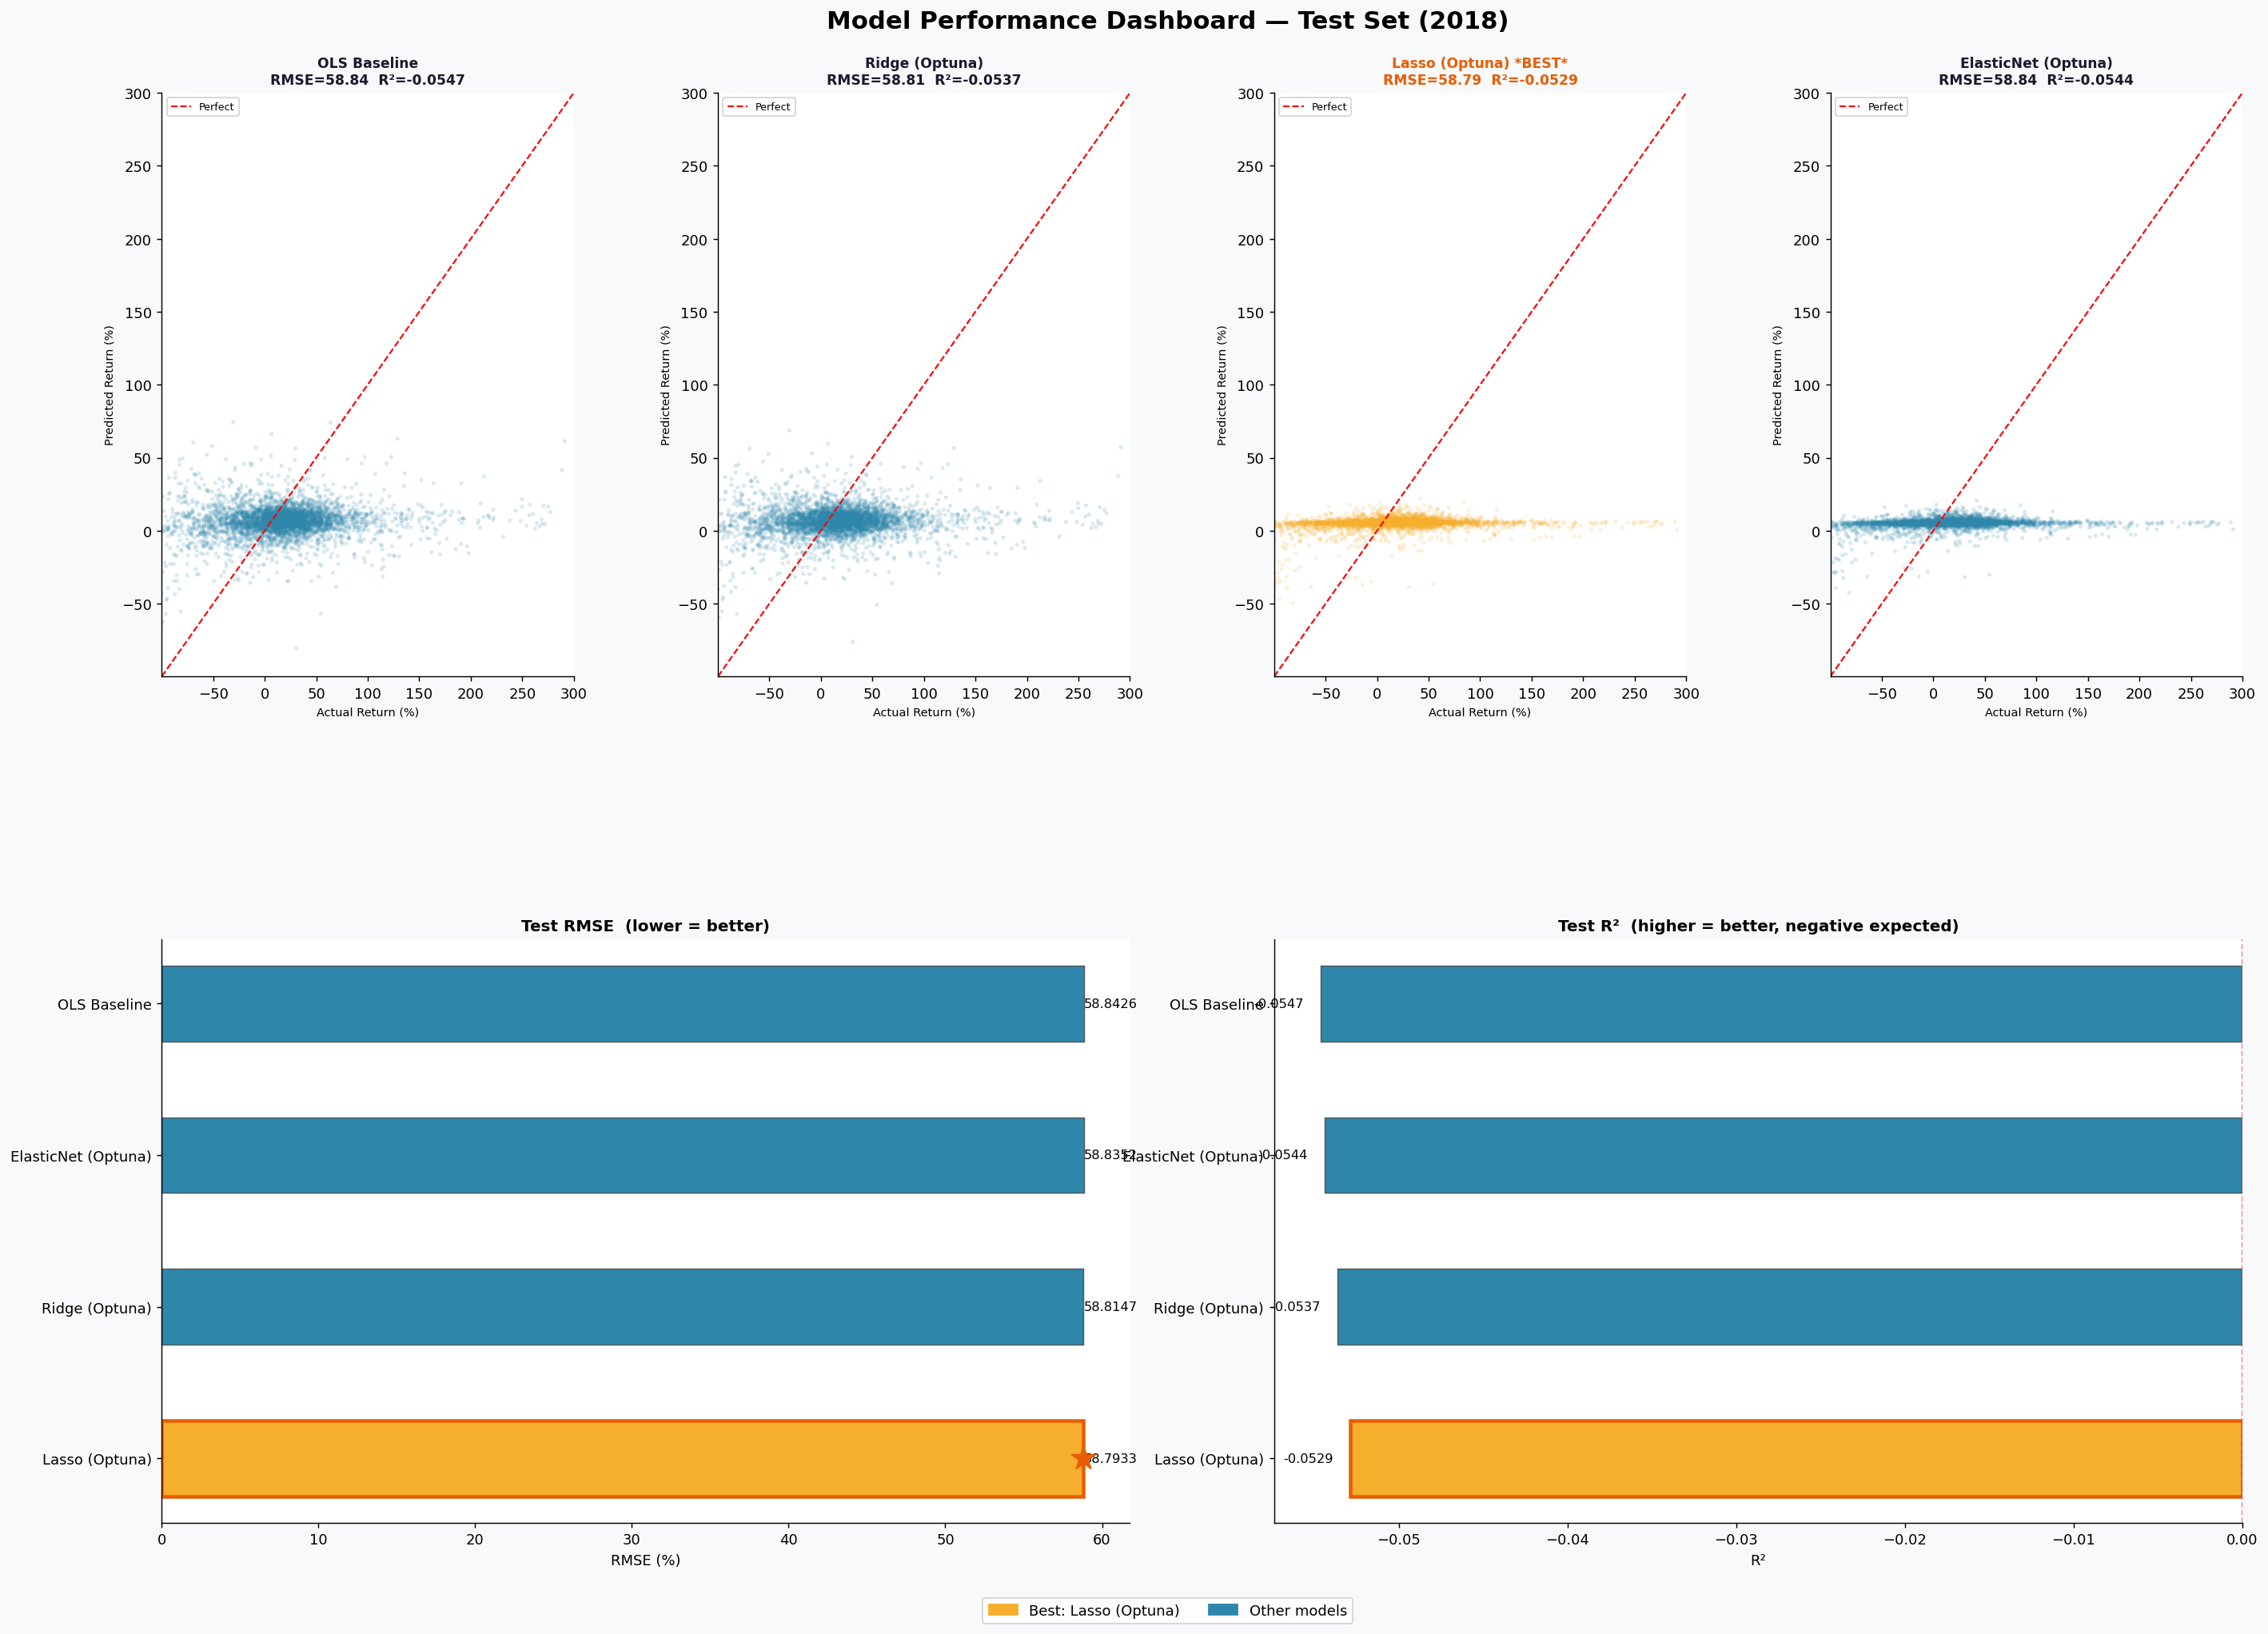

Saved: 02_performance_dashboard.png
Best model: Lasso (Optuna)  RMSE=58.7933  R²=-0.0529


In [32]:
model_names = list(results_df.index)
rmse_vals   = results_df['Test_RMSE'].values.tolist()
r2_vals     = results_df['Test_R2'].values.tolist()
best_idx    = model_names.index(best_model)
palette     = ['#2E86AB'] * len(model_names)
palette[best_idx] = '#F6AE2D'

fig = plt.figure(figsize=(22, 16), facecolor='#F8F9FA')
fig.suptitle('Model Performance Dashboard — Test Set (2018)',
             fontsize=17, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 4, figure=fig,
                       hspace=0.45, wspace=0.35,
                       top=0.93, bottom=0.07, left=0.06, right=0.97)

# Top row: actual vs predicted scatter for each model
for i, (name, preds) in enumerate(all_preds.items()):
    ax = fig.add_subplot(gs[0, i])
    color = '#F6AE2D' if name == best_model else '#2E86AB'
    ax.scatter(y_test.values, preds, alpha=0.18, s=8, color=color, edgecolors='none')
    lims = [max(-100, min(y_test.min(), preds.min())),
            min(300,  max(y_test.max(), preds.max()))]
    ax.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect')
    ax.set_xlim(lims); ax.set_ylim(lims)
    rmse_v = results_df.loc[name, 'Test_RMSE']
    r2_v   = results_df.loc[name, 'Test_R2']
    star   = ' *BEST*' if name == best_model else ''
    ax.set_title(f'{name}{star}\nRMSE={rmse_v:.2f}  R²={r2_v:.4f}',
                 fontsize=9.5, fontweight='bold',
                 color='#E85D04' if name == best_model else '#1a1a2e')
    ax.set_xlabel('Actual Return (%)', fontsize=8)
    ax.set_ylabel('Predicted Return (%)', fontsize=8)
    ax.legend(fontsize=7)

# Bottom left (spans 2): RMSE bar chart
ax_rmse = fig.add_subplot(gs[1, :2])
bars = ax_rmse.barh(model_names, rmse_vals, color=palette,
                    edgecolor='#555', linewidth=0.8, height=0.5)
ax_rmse.set_title('Test RMSE  (lower = better)', fontsize=11, fontweight='bold')
ax_rmse.set_xlabel('RMSE (%)')
for bar, val in zip(bars, rmse_vals):
    ax_rmse.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center', fontsize=9)
bars[best_idx].set_linewidth(2.5)
bars[best_idx].set_edgecolor('#E85D04')
ax_rmse.scatter(rmse_vals[best_idx], best_idx, marker='*', s=300,
                color='#E85D04', zorder=5)

# Bottom right (spans 2): R² bar chart
ax_r2 = fig.add_subplot(gs[1, 2:])
bars2 = ax_r2.barh(model_names, r2_vals, color=palette,
                   edgecolor='#555', linewidth=0.8, height=0.5)
ax_r2.set_title('Test R²  (higher = better, negative expected)',
                fontsize=11, fontweight='bold')
ax_r2.set_xlabel('R²')
ax_r2.axvline(0, color='crimson', linestyle='--', linewidth=1, alpha=0.7)
for bar, val in zip(bars2, r2_vals):
    offset = -0.001 if val < 0 else 0.001
    ha     = 'right' if val < 0 else 'left'
    ax_r2.text(val + offset, bar.get_y() + bar.get_height() / 2,
               f'{val:.4f}', va='center', ha=ha, fontsize=9)
bars2[best_idx].set_linewidth(2.5)
bars2[best_idx].set_edgecolor('#E85D04')

# Legend
gold_p = mpatches.Patch(color='#F6AE2D', label=f'Best: {best_model}')
blue_p = mpatches.Patch(color='#2E86AB', label='Other models')
fig.legend(handles=[gold_p, blue_p], loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, 0.005), frameon=True)

plt.savefig('02_performance_dashboard.png', bbox_inches='tight',
            dpi=150, facecolor='#F8F9FA')
plt.show()
print('Saved: 02_performance_dashboard.png')
print(f'Best model: {best_model}  RMSE={results_df.loc[best_model,"Test_RMSE"]:.4f}  R²={results_df.loc[best_model,"Test_R2"]:.4f}')

---
## Step 12 — Expanding-Window CV Stability

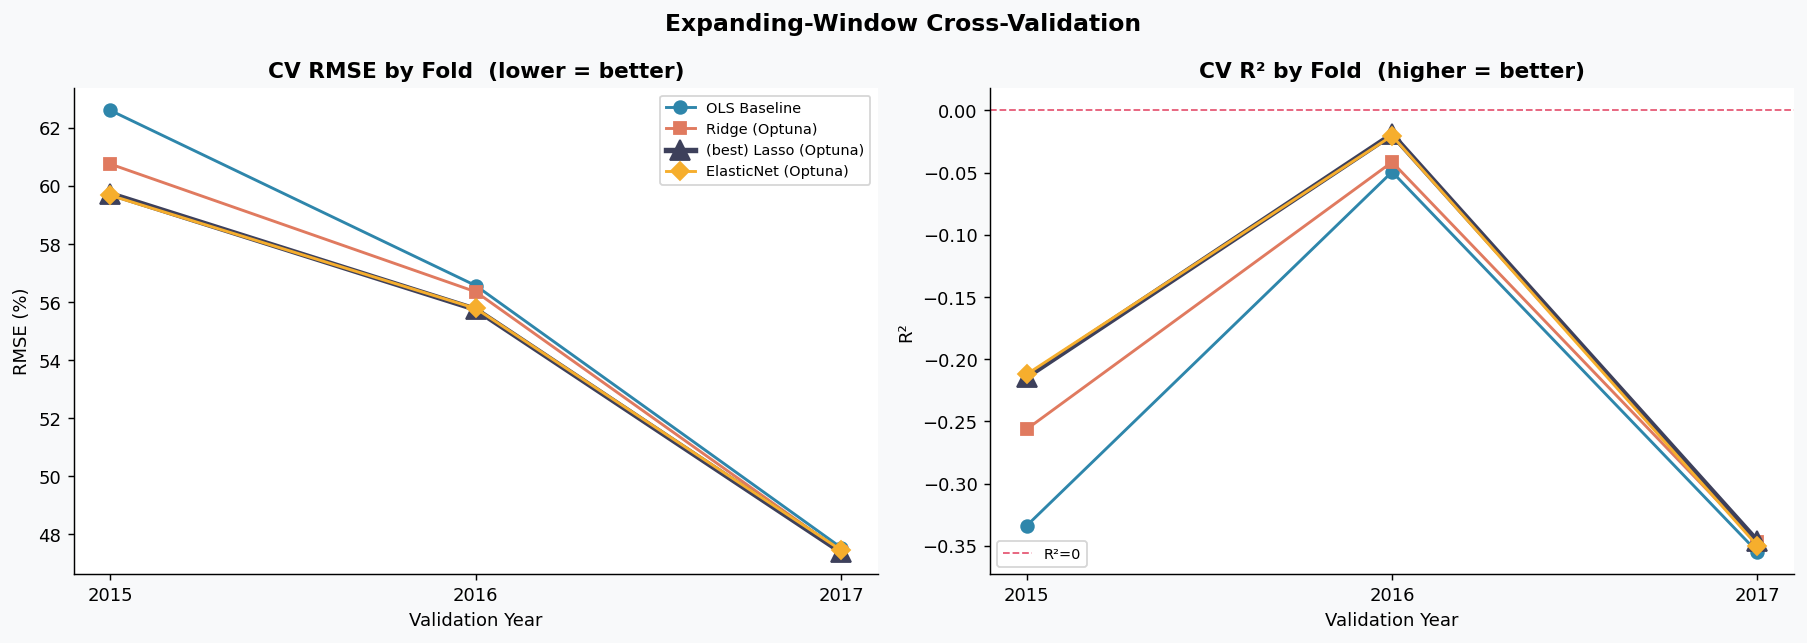

Saved: 03_cv_stability.png


In [33]:
cv_rmse_records = {name: [] for name in all_preds}
cv_r2_records   = {name: [] for name in all_preds}
pipe_map = {
    'OLS Baseline'       : pipe_lr,
    'Ridge (Optuna)'     : best_reg_pipes['Ridge'],
    'Lasso (Optuna)'     : best_reg_pipes['Lasso'],
    'ElasticNet (Optuna)': best_reg_pipes['ElasticNet'],
}
val_years = [v for _, v in CV_SPLITS]

for name, pipe in pipe_map.items():
    for train_yrs, val_yr in CV_SPLITS:
        tr = train_df['Year'].isin(train_yrs)
        va = train_df['Year'] == val_yr
        pipe.fit(X_train_eng.loc[tr, FINAL_FEATS + CAT_FEATS], y_train.loc[tr])
        preds = pipe.predict(X_train_eng.loc[va, FINAL_FEATS + CAT_FEATS])
        cv_rmse_records[name].append(np.sqrt(mean_squared_error(y_train.loc[va], preds)))
        cv_r2_records[name].append(r2_score(y_train.loc[va], preds))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#F8F9FA')
styles = ['-o', '-s', '-^', '-D']
colors = ['#2E86AB', '#E07A5F', '#3D405B', '#F6AE2D']

for (name, rmses), ls, col in zip(cv_rmse_records.items(), styles, colors):
    lw  = 3.0 if name == best_model else 1.6
    ms  = 11  if name == best_model else 7
    lbl = f'(best) {name}' if name == best_model else name
    axes[0].plot(val_years, rmses, ls, label=lbl, color=col, linewidth=lw, markersize=ms)

for (name, r2s), ls, col in zip(cv_r2_records.items(), styles, colors):
    lw  = 3.0 if name == best_model else 1.6
    ms  = 11  if name == best_model else 7
    axes[1].plot(val_years, r2s, ls, color=col, linewidth=lw, markersize=ms)

axes[0].set_title('CV RMSE by Fold  (lower = better)', fontweight='bold')
axes[0].set_xlabel('Validation Year'); axes[0].set_ylabel('RMSE (%)')
axes[0].legend(fontsize=8); axes[0].set_xticks(val_years)

axes[1].set_title('CV R² by Fold  (higher = better)', fontweight='bold')
axes[1].set_xlabel('Validation Year'); axes[1].set_ylabel('R²')
axes[1].axhline(0, color='crimson', linestyle='--', linewidth=1, alpha=0.7, label='R²=0')
axes[1].legend(fontsize=8); axes[1].set_xticks(val_years)

plt.suptitle('Expanding-Window Cross-Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_cv_stability.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: 03_cv_stability.png')

---
## Step 13 — Final Results

In [34]:
print('=' * 55)
print('  FINAL RESULTS - Test Set (2018)')
print('  Metrics: RMSE (primary) + R²')
print('=' * 55)
print(results_df[['Test_RMSE', 'Test_R2']].to_string())
print(f'\nBest model : {best_model}')
print(f'  RMSE     : {results_df.loc[best_model, "Test_RMSE"]:.4f}')
print(f'  R²       : {results_df.loc[best_model, "Test_R2"]:.4f}')

results_df.reset_index().rename(columns={'index': 'Model'}).to_csv(
    'model_results_final.csv', index=False)
print('\nSaved: model_results_final.csv')

print('\nAll output files:')
for f, d in [
    ('model_results_final.csv',      'RMSE + R² leaderboard'),
    ('00_target.png',                'Target distribution'),
    ('01_feature_importance.png',    'Feature importance'),
    ('02_performance_dashboard.png', 'Main dashboard (RMSE + R²)'),
    ('03_cv_stability.png',          'CV RMSE + R² stability'),
]:
    print(f'  {f:<40} {d}')

  FINAL RESULTS - Test Set (2018)
  Metrics: RMSE (primary) + R²
                     Test_RMSE  Test_R2
Lasso (Optuna)         58.7933  -0.0529
Ridge (Optuna)         58.8147  -0.0537
ElasticNet (Optuna)    58.8352  -0.0544
OLS Baseline           58.8426  -0.0547

Best model : Lasso (Optuna)
  RMSE     : 58.7933
  R²       : -0.0529

Saved: model_results_final.csv

All output files:
  model_results_final.csv                  RMSE + R² leaderboard
  00_target.png                            Target distribution
  01_feature_importance.png                Feature importance
  02_performance_dashboard.png             Main dashboard (RMSE + R²)
  03_cv_stability.png                      CV RMSE + R² stability


---
## Summary

| Step | Description |
|------|-------------|
| 1 | Load & combine 3 CSV parts (22,031 rows) |
| 2 | Target: raw `Stock_Return` (%) — no normalisation |
| 3 | Remove leakage: `Class`, `Return_Direction` |
| 4 | Train 2014–2017 / Test 2018 (time-based, no random split) |
| 5 | Feature engineering: winsorisation, signed-log, CS z-score (features only), sector-relative, delta, interactions |
| 6 | Feature selection: variance filter → correlation filter → top 60 by Pearson r |
| 7 | Preprocessor (impute + scale + one-hot) + CV RMSE helper |
| 8 | Exp 1: OLS baseline |
| 9 | Exp 2: Ridge / Lasso / ElasticNet — Optuna minimises CV-RMSE (100 trials) |
| 10 | Collect all test-set RMSE results |
| 11 | Dashboard: actual vs predicted + RMSE comparison + residuals |
| 12 | Expanding-window CV RMSE stability |
| 13 | Final leaderboard saved to CSV |